# Projekt 1
### Maciej Flaga

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import time
from math import sqrt

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBALS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# Omówienie metod

## Metoda diagonalizacji
Celem jest rozwiązanie równania Schroedingera niezależnego od czasu w jednym wymiarze w postaci
$$
-\frac{\hbar^2}{2m}\frac{d^2}{dx^2}\psi(x)+V(x)\psi(x)=E\psi(x)
$$ 
W tym celu dyskretyzujemy równanie dzieląc obszar $[-\frac{L}{2}, \frac{L}{2}]$ na N częsci otrzymując wzór na j-ty węzęł 
$$
x_j=-\frac{L}{2}+j\Delta x, \quad j=0,1,...,N
$$
, gdzie $\Delta x=\frac{L}{N}$. Stosując przybliżenie drugiej pochodnej jako centralny iloraz różnicowy 
$$
\frac{d^2\psi}{dx^2}\approx \frac{\psi_{j+1}-2\psi_j+\psi_{j-1}}{(\Delta x)^2}
$$
oraz oznaczenie
$$
t = \frac{\hbar^2}{2m(\Delta x)^2}
$$
i wstawiając do równania wyjściowego otrzymujemy
$$
-t\psi_{j+1}+(2t+V_j)\psi_j-t\psi_{j-1}=E\psi_j
$$
Po uwzglęnieniu warunków przegowych w postaci $\psi_0=\psi_N=0$ otrzymujemy problem własny opisany kwadratową macierzą trójdiagonalną
$$
\begin{bmatrix}
2t+V_1 & -t & 0 & \cdots & 0\\
-t & 2t+V_2 & -t & \cdots & 0\\
0 & -t & 2t+V_3 & \cdots & 0\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
0 & 0 & \cdots & -t & 2t+V_{N-1}
\end{bmatrix}
\begin{bmatrix}
\psi_1\\
\psi_2\\
\psi_3\\
\vdots\\
\psi_{N-1}
\end{bmatrix}
=
E
\begin{bmatrix}
\psi_1\\
\psi_2\\
\psi_3\\
\vdots\\
\psi_{N-1}
\end{bmatrix}
$$
który zapiszemy w postaci
$$
\hat{H}\psi_n=E_n\psi_n
$$
Macierz hamiltonianu jest hermitowska co pozwala nam rozwiązać problem korzystając z zoptymalizowanego algorytmu diagonalizacji $\texttt{numpy.linalg.eigh}$. Zaprogramowano funkcję rozwiązującą problem własny dla danego $L, N, V, \hbar, m, k$, gdzie $k$ jest górną liczbą interesujących nas stanów. Funkcja zwraca wartości własne tj. poziomy energii $E_n$; Wektory własne tj. funkcje własne układu $\psi_n$; czas działania algorytmu

In [3]:
def met_diag(L,N,V,hbar,m,k):
    t0 = time.time() # stoper start
    dx=L/N # krok prszestrzenny
    t=hbar**2/(2*m*dx*dx) # parametr t
    H=np.zeros((N-2)**2).reshape((N-2,N-2)) # alokacja hamiltonianu
    for i in range(N-2):
        H[i][i]=2*t+V[i+1] # diagonala
    for i in range(N-3):
        H[i+1][i]=-t # poddiagonala
        H[i][i+1]=-t # naddiagonala
    eigvals, eigvecs = np.linalg.eigh(H) # diagonalizacja
    keigvals = np.zeros(k) # alokacja k pierwszych wartosci wł
    keigvecs = np.zeros(k*(N)).reshape((k,N)) # alokacja k pierwszych wektorów wł
    for i in range(k):
        keigvals[i] = eigvals[i] # kopiowanie
        keigvecs[i, 1:-1] = eigvecs[:, i] # kopiowanie
    # normalizacja
    norm = 0
    for i in range(len(keigvecs[0])):
        norm += abs(keigvecs[0][i])**2*dx
    keigvecs = keigvecs/sqrt(norm)
    t1=time.time() # stoper stop
    return keigvals, keigvecs, t1-t0

## Metoda strzałów

Ta metoda opiera się na potraktowaniu problemu jak dla dynamiki cząstki tj. zamienienie problemu brzegowego na problem początkowy. Przekształcamy równanie do postaci
$$
\frac{d^2\psi_n(x)}{dx^2}=\left[ \frac{2m}{\hbar^2}V(x)-k^2 \right]\psi_n(x),
$$
gdzie $k^2=2mE/\hbar^2$. Wiemy, że $\psi(0)=0$ oraz ustawiamy $\psi '(0)$ na dowolną wartość, tutaj $1$. Możemy tak zrobić ponieważ ostatecznie jedyną konsekwencją będzie wartość normy funkcji falowej co możemy łatwo naprawić normując funkcję falową do jedynki po uzyskaniu wyniku. Takie równanie rozwiązujemy numerycznie stosując metodę Eulera, które, po dyskretyzacji siatki oraz zastosowaniu oznaczeń $\psi=u;\ \psi ' = v$, opisuje układ równań
$$
\begin{cases}
u_{j+1}=u_j+u'_j\Delta x=u_j+v_j\Delta x\\
v_{j+1}=v_j+v'_j\Delta x = v_j+(\frac{2m}{\hbar^2}V_j-k^2)u_j\Delta x\\
u_0=0\\
v_0=1
\end{cases}
$$
Warunkiem jaki musimy narzucić na wartość liczby falowej $k$ jest $\psi(L)=0$ czego byśmy oczekiwali od naszego rozwiązania. Nie wiemy dla jakiego $k$ ten warunek będzie spełniony więc musimy strzelać. Przy każdym strzale analizujemy funkcję błędu zdefiniowaną jako
$$
f_\delta(k)=\psi^k(L)\approx 0
$$
i będziemy szukać jej miejsca zerowego metodą bisekcji aż do osiągnięcia zadanej tolerancji $\delta$. Chcemy również mieć kontrolę nad stanem eneretycznym, dla którego rozwiązujemy nasze równanie. Powołamy się tutaj na twierdzenie o węzłach, które mówi że w jednym wymiarze liczba węzłów funkcji falowej jest równa $n-1$, gdzie $n$ jest danym stanem. Wykorzystamy to twierdzenie wraz z faktem, że dla wyższych stanów spodziewamy się wyższej energii. Przy każdym strzale będziemy zliczać węzły i powtarzać obliczenia dla odpowiednio zmienionego $k$ jeżeli stan się nie zgadza. Poniżej implementacja metody strzałów insipirowana pseudokodem z wykładu.

In [4]:
def met_strz(L,N,V,hbar,m,k,delta):
    t0=time.time() # stoper start
    dx=L/N # krok przestrzenny
    psi=np.zeros(N*k).reshape((k,N)) # alokacja macierzy funkcji wl
    E=np.zeros(k) # alokacja wektora energii
    for n in range(k): # pętla po pierwszych k stanach
        fbledu=10000 # duza liczba
        kP=100 # przedzial liczby falowej k
        kL=-100
        while ((abs(fbledu)>delta) & (kP-kL>dx)): # pętla i warnuke stopu
            kp=(kL+kP)/2 # bisekcja 
            u=0
            v=1
            nodes=0
            for i in range(N-1): # schemat Eulera
                un=u+v*dx
                vn=v+(2*m*V[i]/(hbar**2)-kp**2)*u*dx
                psi[n][i+1]=un
                if (psi[n][i]*psi[n][i+1]<0): # zliczanie węzłów
                    nodes=nodes+1
                u=un
                v=vn
            fbledu=psi[n][N-1] # funkcja bledu jako psi(L)
            if (nodes<=n): # przesuwanie przedziału ze względu na stan
                kL=kp
            else:
                kP=kp
        norm=0 # normalizacja
        for i in range(N):
            norm+=abs(psi[n][i])**2*dx
        psi[n]=psi[n]/sqrt(norm)
        E[n]=kp**2*hbar**2/(2*m) # energia
    t1=time.time() # stoepr stop
    return psi, E, t1-t0


# Rozwiązanie problemów

## Nieskończona studnia potencjału
Opisana potencjałem
$$
V(x)=
\begin{cases}
0, \quad x\in[-\frac{L}{2}; \frac{L}{2}]\\
\infty, \quad x\notin[-\frac{L}{2}; \frac{L}{2}]
\end{cases}
$$

Przyjęto parametry jak poniżej

In [5]:
# parametry
L=5
N=4000
dx=L/N
n = [1,3,12,19]
n = np.subtract(n,1)
hbar=1
m=1

In [6]:
# inicjalizacja
x = np.linspace(-L/2,L/2,N)
V = np.zeros(N)

Analityczne rozwiązanie układu
$$
\psi_n=
\begin{cases}
\sqrt{\frac{2}{L}}\cos{(\frac{n\pi x}{L})}, \quad n \text{ nieparzyste}\\
\sqrt{\frac{2}{L}}\sin{(\frac{n\pi x}{L})}, \quad n \text{ parzyste}
\end{cases}
$$
$$
E_n=\frac{n^2\pi^2\hbar^2}{2mL^2}
$$

In [7]:
apsi1 = sqrt(2/L)*np.cos((n[0]+1)*np.pi*x/L)
apsi3 = sqrt(2/L)*np.cos((n[1]+1)*np.pi*x/L)
apsi12 = sqrt(2/L)*np.sin((n[2]+1)*np.pi*x/L)
apsi19 = sqrt(2/L)*np.cos((n[3]+1)*np.pi*x/L)

In [8]:
# diagonalizacja
diag_evals, diag_evecs, diag_czas = met_diag(L,N,V,hbar,m,k=max(n)+1)
print(f'Czas diagonalizacji: {diag_czas:.4f}s')

Czas diagonalizacji: 2.6399s


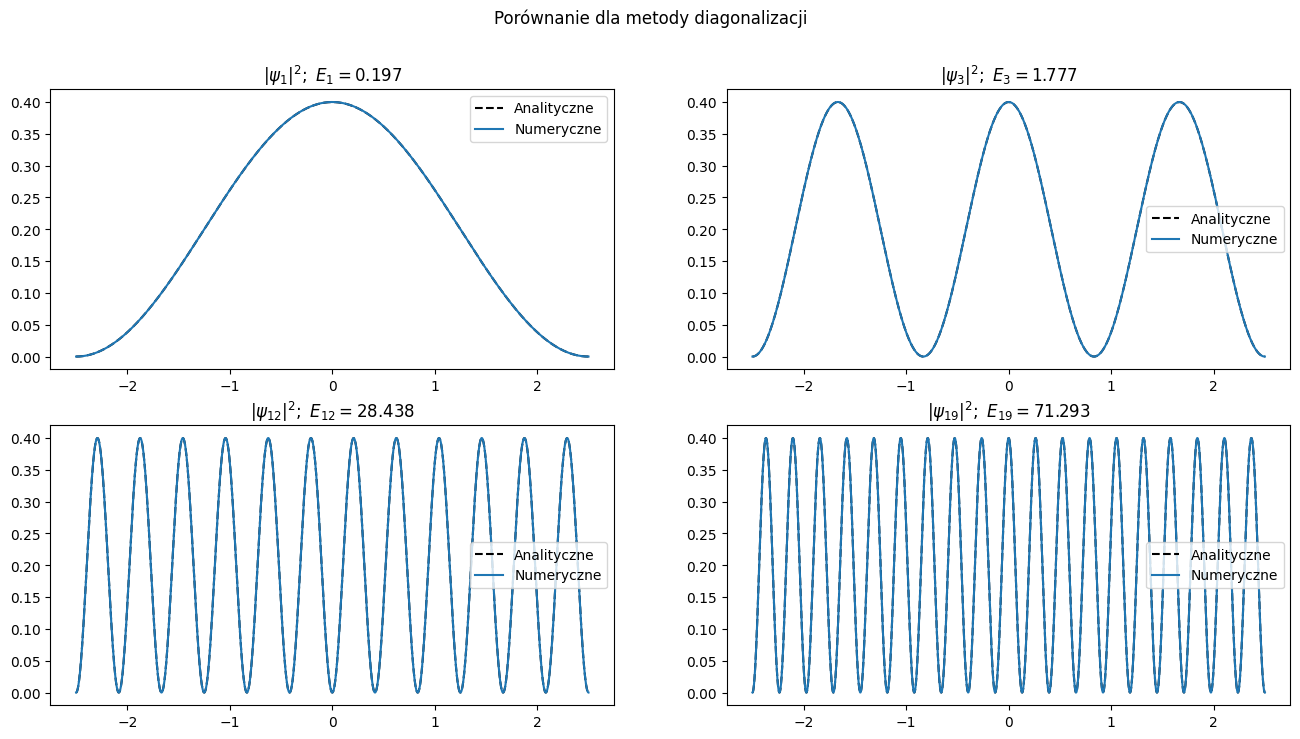

In [9]:
# wykres
fig, axs = plt.subplots(2,2,figsize=(16,8))

fig.suptitle('Porównanie dla metody diagonalizacji')

k=n[0]
axs[0,0].plot(x,np.abs(apsi1)**2,linestyle='--',color='black', label='Analityczne')
axs[0,0].plot(x,np.abs(diag_evecs[k,:])**2,label='Numeryczne')
axs[0,0].set_title(rf'$|\psi_{{{k+1}}}|^2;\ E_{{{k+1}}}={diag_evals[k]:.3f}$')
axs[0,0].legend()

k=n[1]
axs[0,1].plot(x,np.abs(apsi3)**2,linestyle='--',color='black', label='Analityczne')
axs[0,1].plot(x,np.abs(diag_evecs[k,:])**2,label='Numeryczne')
axs[0,1].set_title(rf'$|\psi_{{{k+1}}}|^2;\ E_{{{k+1}}}={diag_evals[k]:.3f}$')
axs[0,1].legend()

k=n[2]
axs[1,0].plot(x,np.abs(apsi12)**2,linestyle='--',color='black', label='Analityczne')
axs[1,0].plot(x,np.abs(diag_evecs[k,:])**2,label='Numeryczne')
axs[1,0].set_title(rf'$|\psi_{{{k+1}}}|^2;\ E_{{{k+1}}}={diag_evals[k]:.3f}$')
axs[1,0].legend()

k=n[3]
axs[1,1].plot(x,np.abs(apsi19)**2,linestyle='--',color='black', label='Analityczne')
axs[1,1].plot(x,np.abs(diag_evecs[k,:])**2,label='Numeryczne')
axs[1,1].set_title(rf'$|\psi_{{{k+1}}}|^2;\ E_{{{k+1}}}={diag_evals[k]:.3f}$')
axs[1,1].legend()

# for k in n:
#     plt.plot(x,np.abs(diag_evecs[k,:])**2,label=rf'$E_{{{k+1}}}={diag_evals[k]:.2f}$')
#     plt.legend()
plt.show()

In [10]:
# porównanie
E_analiticzne = np.pi*np.pi*hbar*hbar/(2*m*L*L)*np.pow(np.add(n,1),2)
E_wyznaczone = np.array([diag_evals[n[0]], diag_evals[n[1]], diag_evals[n[2]], diag_evals[n[3]]])
bl_bzw = np.abs(E_analiticzne-E_wyznaczone)
bl_wz = bl_bzw/E_analiticzne
print(f'Energie analityczne:\t{E_analiticzne}')
print(f'Energie numeryczne:\t{E_wyznaczone}')
print(f'Błędy bezwzględne:\t{bl_bzw}')
print(f'Błędy względne:\t\t{bl_wz}')

Energie analityczne:	[ 0.19739209  1.77652879 28.42446068 71.25854378]
Energie numeryczne:	[ 0.19749081  1.77741657 28.43846762 71.29286276]
Błędy bezwzględne:	[9.87229938e-05 8.87774978e-04 1.40069482e-02 3.43189855e-02]
Błędy względne:		[0.00050014 0.00049972 0.00049278 0.00048161]


Dla N=4000 uzyskano największy błąd względny 0.050% przy czasie diagonalizacji 2.45 s.  
Dla N=6000 uzyskano największy błąd względny 0.033% przy czasie diagonalizacji 11.60 s.  
Dla N=12000 uzyskano największy błąd względny 0.017% przy czasie diagonalizacji 79.67 s.  
  
Nie próbowano większych wartości N

### Porównanie metod przy wyznaczeniu wszystkich wektorów i wartości własnych 
Obliczenia przeprowadzimy dla N=1000; $\delta$=0.0001=0.01%  

In [11]:
N=1000
d=0.0001
test1, test2, test3 = met_diag(L,N,V,hbar,m,N-3)
test4, test5, test6 = met_strz(L,N,V,hbar,m,N-3,d)
print(f'Czas diagonalizacji:\t{test3:.3f}s')
print(f'Czas strzałów:\t\t{test6:.3f}s')

Czas diagonalizacji:	0.068s
Czas strzałów:		9.286s


Z racji, że to jest pierwszy raz jak używamy metody strzałów warto zobaczyć wyniki w celu walidacji/analizy. Posłużono się już wcześniej napisanym kodem do wykresów.

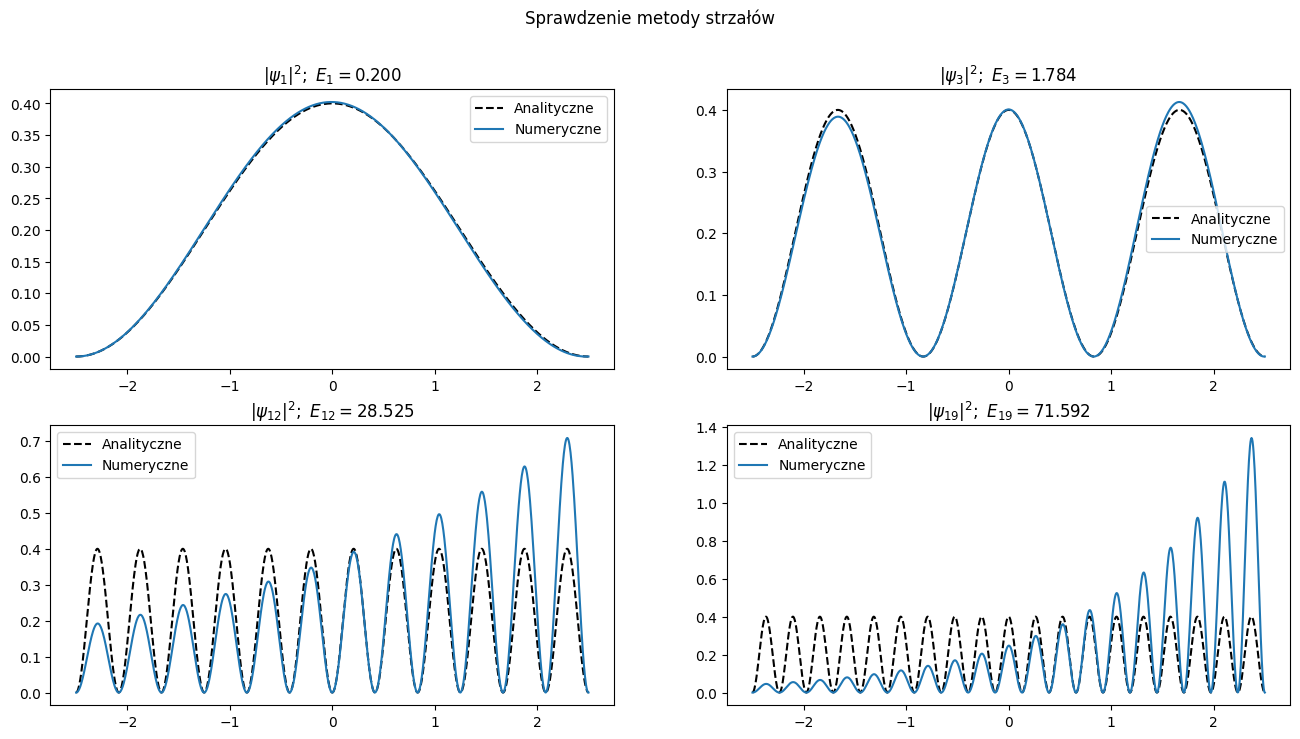

In [12]:
# wykres
x = np.linspace(-L/2,L/2,N)
apsi1 = sqrt(2/L)*np.cos((n[0]+1)*np.pi*x/L)
apsi3 = sqrt(2/L)*np.cos((n[1]+1)*np.pi*x/L)
apsi12 = sqrt(2/L)*np.sin((n[2]+1)*np.pi*x/L)
apsi19 = sqrt(2/L)*np.cos((n[3]+1)*np.pi*x/L)
fig, axs = plt.subplots(2,2,figsize=(16,8))

fig.suptitle('Sprawdzenie metody strzałów')

k=n[0]
axs[0,0].plot(x,np.abs(apsi1)**2,linestyle='--',color='black', label='Analityczne')
axs[0,0].plot(x,np.abs(test4[k,:])**2,label='Numeryczne')
axs[0,0].set_title(rf'$|\psi_{{{k+1}}}|^2;\ E_{{{k+1}}}={test5[k]:.3f}$')
axs[0,0].legend()

k=n[1]
axs[0,1].plot(x,np.abs(apsi3)**2,linestyle='--',color='black', label='Analityczne')
axs[0,1].plot(x,np.abs(test4[k,:])**2,label='Numeryczne')
axs[0,1].set_title(rf'$|\psi_{{{k+1}}}|^2;\ E_{{{k+1}}}={test5[k]:.3f}$')
axs[0,1].legend()

k=n[2]
axs[1,0].plot(x,np.abs(apsi12)**2,linestyle='--',color='black', label='Analityczne')
axs[1,0].plot(x,np.abs(test4[k,:])**2,label='Numeryczne')
axs[1,0].set_title(rf'$|\psi_{{{k+1}}}|^2;\ E_{{{k+1}}}={test5[k]:.3f}$')
axs[1,0].legend()

k=n[3]
axs[1,1].plot(x,np.abs(apsi19)**2,linestyle='--',color='black', label='Analityczne')
axs[1,1].plot(x,np.abs(test4[k,:])**2,label='Numeryczne')
axs[1,1].set_title(rf'$|\psi_{{{k+1}}}|^2;\ E_{{{k+1}}}={test5[k]:.3f}$')
axs[1,1].legend()

# for k in n:
#     plt.plot(x,np.abs(diag_evecs[k,:])**2,label=rf'$E_{{{k+1}}}={diag_evals[k]:.2f}$')
#     plt.legend()
plt.show()

Widzimy, że metoda strzałów zajmuje znacznie więcej czasu obliczeniowego oraz uzyskane wyniki odbiegają znacząco od analitycznych.

## Oscylator harmoniczny / Paraboliczny potencjał
Opisany potencjałem
$$
V(x)=
\begin{cases}
V_0x^2, \quad x\in [-\frac{L}{2}; \frac{L}{2}]\\
\infty, \quad x\notin [-\frac{L}{2}; \frac{L}{2}]
\end{cases}
$$

In [13]:
# parametry
N = 1000
x = np.linspace(-L/2,L/2,N)
V0 = 5
V = V0*x*x
# print(L/N)

Obliczenia zostaną przeprowadzone za pomocą metody diagonalizacji

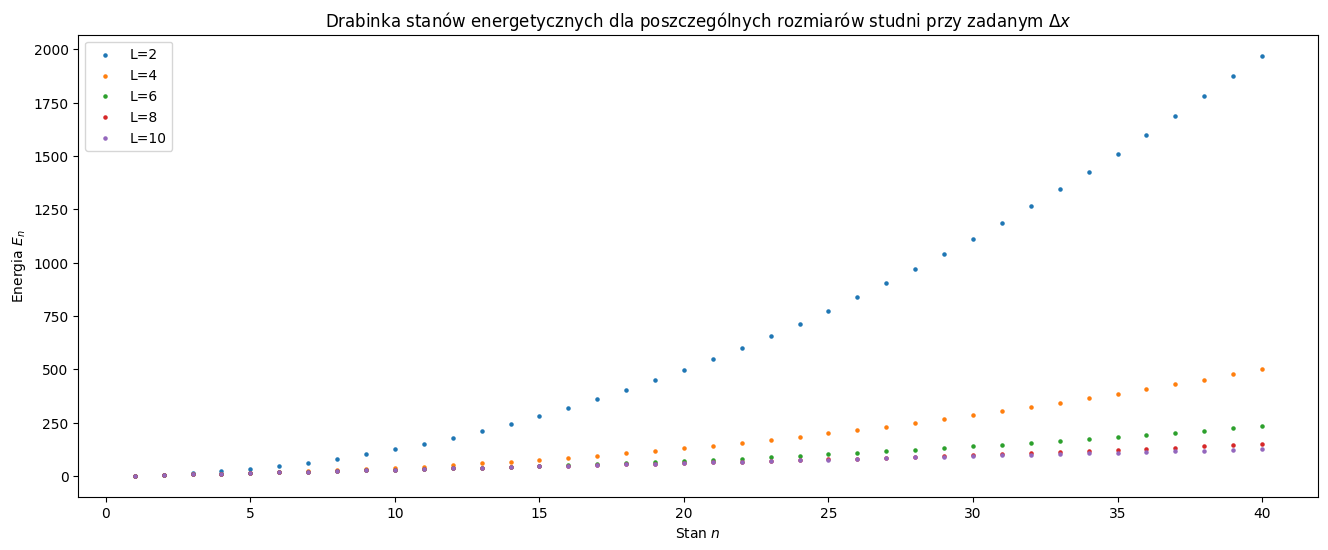

In [14]:
plt.figure(figsize=(16,6))
plt.title(rf'Drabinka stanów energetycznych dla poszczególnych rozmiarów studni przy zadanym $\Delta x$')
plt.xlabel(rf'Stan $n$')
plt.ylabel(rf'Energia $E_n$')
for L in np.arange(2,12,2):
    N=int(L/0.005)
    x = np.linspace(-L/2,L/2,N)
    V = V0*x*x
    osc_ww, osc_fw, osc_czas = met_diag(L,N,V,hbar,m,40)
    plt.scatter(np.add(range(40),1),osc_ww,label=f'L={L}',s=5)
plt.legend()
plt.show()

Widzimy, że zwiększając rozmiar studni drabinka stanów się rozpłaszcza tzn. z zależności kwadratowej przechodzimy w liniową. Spodziewaliśmy się tego ponieważ zmniejszamy wpływ studni na układ i dominuje potencjał oscylatora. Drabinka energii zmienia się jak
$$
E_n:\quad\frac{n^2\pi^2\hbar^2}{2mL^2}\to \hbar\omega\left(n+\frac{1}{2}\right)
$$

## Skończona studnia
Opisana potencjałem
$$
V=
\begin{cases}
0, \quad x\in[-\frac{L}{2};-\frac{L}{6})\cup(\frac{L}{6};\frac{L}{2}]\\
-|V_0|, \quad x\in[-\frac{L}{6};\frac{L}{6}]\\
\infty, \quad x\notin[-\frac{L}{2}; \frac{L}{2}]
\end{cases}
$$

In [15]:
# parametry
N=1000
L=5
V0=10
x=np.linspace(-L/2,L/2,N)
V=np.zeros(N)
for i in range(N):
    if (x[i]>=-L/6 and x[i]<=L/6):
        V[i]=-abs(V0)

### Metodą diagonalizacji

In [16]:
ssd_ww, ssd_fw, ssd_czas = met_diag(L,N,V,hbar,m,N-3)

In [17]:
licznik=0
for i in range(N-3):
    if ssd_ww[i]<0:
        licznik+=1
print(f'Liczba ujemnych stanów: {licznik}')

Liczba ujemnych stanów: 3


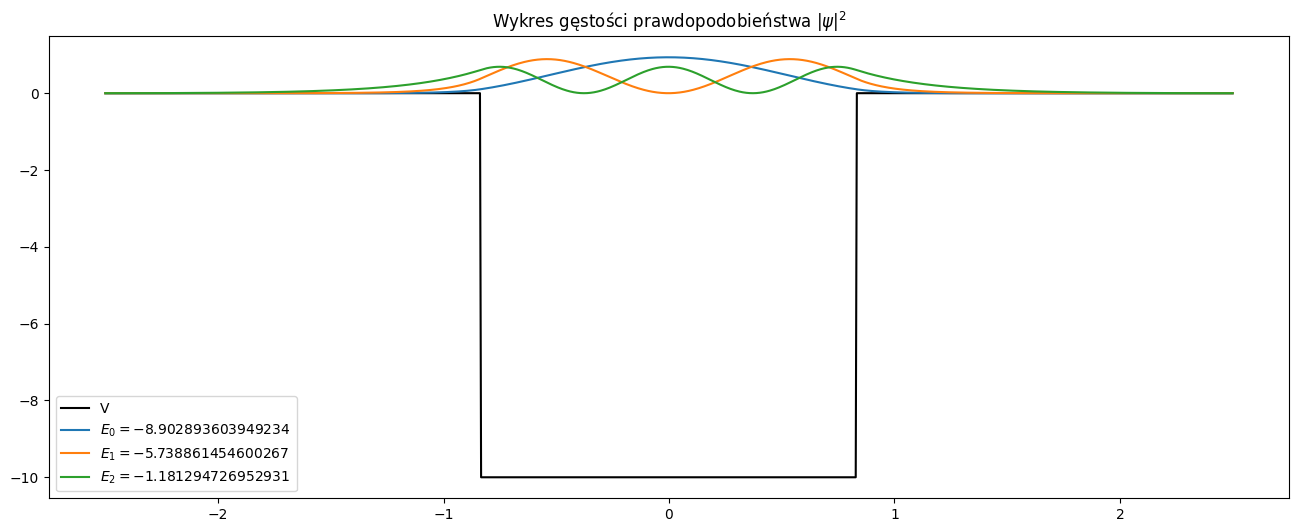

In [18]:
plt.figure(figsize=(16,6))
plt.plot(x,V,color='black',label='V')
plt.title(rf'Wykres gęstości prawdopodobieństwa $|\psi|^2$')
for i in range(licznik):
    plt.plot(x,np.abs(ssd_fw[i,:])**2,label=rf'$E_{{{i}}}={ssd_ww[i]}$')
plt.legend()
plt.show()

Przesuniemy potencjał do góry tak aby lepiej widzieć sytuację

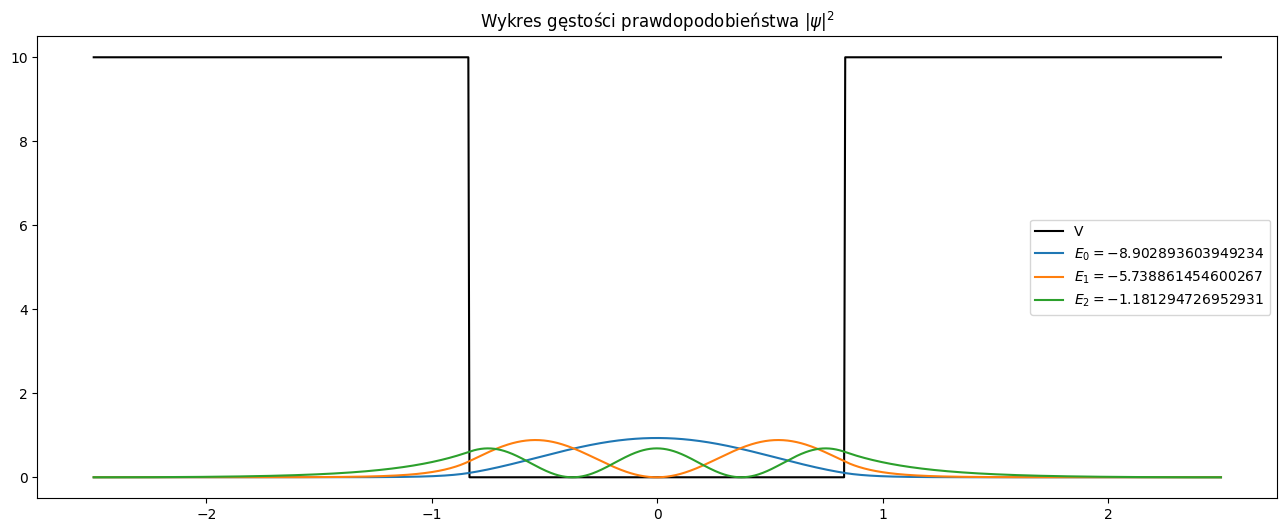

In [19]:
plt.figure(figsize=(16,6))
plt.plot(x,np.add(V,abs(V0)),color='black',label='V')
plt.title(rf'Wykres gęstości prawdopodobieństwa $|\psi|^2$')
for i in range(licznik):
    plt.plot(x,np.abs(ssd_fw[i,:])**2,label=rf'$E_{{{i}}}={ssd_ww[i]}$')
plt.legend()
plt.show()

Widzimy, że w obszarze klasycznie wzbronionym możemy wciąż znaleźć cząstkę jeżeli mamy do czynienia z układem kwantowym.

### Metodą strzałów

In [20]:
# parametry
N=1000
L=5
V0=10
x=np.linspace(-L/2,L/2,N)
V=np.zeros(N)
for i in range(N):
    if (x[i]>=-L/6 and x[i]<=L/6):
        V[i]=-abs(V0)

In [21]:
sss_fw, sss_ww, sss_czas = met_strz(L,N,V,hbar,m,licznik+10, 0.000001)

In [22]:
licznik=0
for i in range(licznik+10):
    if sss_ww[i]<0:
        licznik+=1
print(f'Liczba ujemnych stanów: {licznik}')

Liczba ujemnych stanów: 0


Widzimy, że nawet dla zadanej tolenracji błędu 0.0001% metoda strzałów nie znajduje żadnego stanu o ujemnej energii. Należy naprawić metodę implementując metodę dwukierunkową.